## Dags att labba med lite modellering och försöka hitta en skön funktion för att styra mitt "smarta hem".

In [ ]:
# Lite housekeeping - en del grejer är fragment från tidigare experiment, men de får stå kvar.

import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
from io import StringIO
from datetime import datetime, timedelta
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance
import lightgbm as lgb
import optuna
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, r2_score 
optuna.logging.set_verbosity(optuna.logging.WARNING)
import calendar
from datetime import datetime, timedelta



warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.3f}'.format)

# ── Konstanter ──
LAT, LON      = 56.67, 12.86          # Halmstad
STATION_ID    = 62410                  # Halmstad Flygplats
MASTER_CSV    = "Datainsamling/Del 3 - Data för projektet/master_energy_data_cleaned.csv"
TRAIN_CUTOFF  = "2025-07-01"          # Allt före = träning
STRANG_PARAM  = 117                    # Global irradians W/m²


In [51]:
# Ladda in data från CSV-filen
df_master = pd.read_csv(MASTER_CSV, parse_dates=['timestamp'])
df_master = df_master.sort_values('timestamp').set_index('timestamp')

print(f"Rader:   {len(df_master):,}")
print(f"Kolumner: {df_master.columns.tolist()}")
print(f"Period:  {df_master.index.min()} → {df_master.index.max()}")
df_master.head(3)

Rader:   21,961
Kolumner: ['hour', 'weekday', 'is_weekend', 'month', 'season', 'hour_sin', 'hour_cos', 'temp_c', 'irradiance_wm2', 'grid_import_kwh', 'grid_export_kwh', 'total_production_kwh', 'self_consumption_kwh', 'total_house_load_kwh', 'net_balance_kwh', 'price_total_ore']
Period:  2023-07-01 00:00:00 → 2025-12-31 23:00:00


,hour,weekday,is_weekend,month,season,hour_sin,hour_cos,temp_c,irradiance_wm2,grid_import_kwh,grid_export_kwh,total_production_kwh,self_consumption_kwh,total_house_load_kwh,net_balance_kwh,price_total_ore
timestamp,,,,,,,,,,,,,,,,
2023-07-01 00:00:00,0,5,1,7,summer,0.000,1.000,14.239,0.000,0.800,0.000,0.000,0.000,0.800,-0.800,0.000
2023-07-01 01:00:00,1,5,1,7,summer,0.259,0.966,14.938,0.000,2.400,0.000,0.000,0.000,2.400,-2.400,34.859
2023-07-01 02:00:00,2,5,1,7,summer,0.500,0.866,16.050,0.000,6.000,0.000,0.000,0.000,6.000,-6.000,34.481


In [39]:
def fetch_strang_hourly(lat, lon, param, date_from, date_to):
    """
    Jag hade inte koll på att även SMHI (via STRÅNG) har timvis data för solinstrålning 
    så jag kompletterar mina NASA-data med dessa.
    Returnerar en pd.Series med DateTime-index (Europe/Stockholm).
    Saknade värden (-999) ersätts med NaN.
    """
    from_str = date_from.strftime('%Y%m%d%H')   # format: YYYYMMDDHH
    to_str   = date_to.strftime('%Y%m%d%H')

    url = (
        f"https://opendata-download-metanalys.smhi.se/api/category/strang1g"
        f"/version/1/geotype/point/lon/{lon}/lat/{lat}"
        f"/parameter/{param}/data.txt"
        f"?from={from_str}&to={to_str}&interval=hourly"
    )
    print(f"Hämtar: {url}")
    r = requests.get(url, timeout=60)
    r.raise_for_status()

    # Parsa ASCII: år mån dag timme värde
    rows = []
    for line in r.text.strip().splitlines():
        parts = line.split()
        if len(parts) == 5:
            try:
                ts = pd.Timestamp(year=int(parts[0]), month=int(parts[1]),
                  day=int(parts[2]), hour=int(parts[3]),
                  tz='UTC'
                ).tz_convert('Europe/Stockholm').tz_localize(None)
                val = float(parts[4])
                rows.append((ts, val))
            except ValueError:
                continue

    s = pd.Series(
        {ts: v for ts, v in rows},
        name='strang_ghi_wm2'
    )
    s = s.replace(-999, np.nan)   # Saknade värden → NaN
    print(f"STRÅNG: {len(s):,} timmar | "
          f"Saknade: {s.isna().sum()} | "
          f"Max: {s.max():.0f} W/m²")
    return s

# Hämta hela perioden
date_from = datetime(2023, 7, 1, 0)
date_to   = datetime(2025, 12, 31, 23)
strang_series = fetch_strang_hourly(LAT, LON, STRANG_PARAM, date_from, date_to)
strang_series.head()


Hämtar: https://opendata-download-metanalys.smhi.se/api/category/strang1g/version/1/geotype/point/lon/12.86/lat/56.67/parameter/117/data.txt?from=2023070100&to=2025123123&interval=hourly
STRÅNG: 21,957 timmar | Saknade: 192 | Max: 871 W/m²


2023-07-01 02:00:00    0.000
2023-07-01 03:00:00    0.000
2023-07-01 04:00:00    0.000
2023-07-01 05:00:00    8.200
2023-07-01 06:00:00   54.300
Name: strang_ghi_wm2, dtype: float64

In [40]:
def fetch_metobs_temperature(station_id):
    """
    Hämtar timvis lufttemperatur (parameter 1) från SMHI metobs.
    Kombinerar corrected-archive + latest-months automatiskt.
    Returnerar en pd.Series med DateTime-index (UTC→Europe/Stockholm).
    """
    base = "https://opendata-download-metobs.smhi.se/api/version/1.0"
    frames = []

    for period in ['corrected-archive', 'latest-months']:
        url = f"{base}/parameter/1/station/{station_id}/period/{period}/data.csv"
        try:
            r = requests.get(url, timeout=30)
            r.raise_for_status()
            # SMHI CSV har metadata-rader i toppen — hoppa över dem
            lines = r.content.decode('utf-8-sig').splitlines()
            data_start = next(
                i for i, l in enumerate(lines)
                if l.startswith('Datum') or l.startswith('datum')
            )
            csv_text = '\n'.join(lines[data_start:])
            tmp = pd.read_csv(
                StringIO(csv_text),
                sep=';',
                usecols=[0, 1, 2],
                names=['datum', 'tid_utc', 'temp_obs'],
                skiprows=1,
                dtype={'temp_obs': str}
            )
            tmp['timestamp'] = pd.to_datetime(
                tmp['datum'] + ' ' + tmp['tid_utc'],
                utc=True,           # SMHI kör UTC av någon anledning
                errors='coerce'
            ).dt.tz_convert('Europe/Stockholm').dt.tz_localize(None)  # → lokal tid
            tmp['temp_obs'] = pd.to_numeric(tmp['temp_obs'], errors='coerce')
            frames.append(tmp[['timestamp', 'temp_obs']].dropna())
            print(f"  Period '{period}': {len(tmp)} rader")
        except Exception as e:
            print(f"  Period '{period}': hoppades över ({e})")

    df_obs = pd.concat(frames).drop_duplicates('timestamp')
    df_obs = df_obs.set_index('timestamp').sort_index()['temp_obs']
    df_obs.name = 'temp_obs_c'
    print(f"\nmetobs temp: {len(df_obs):,} timmar | "
          f"Period: {df_obs.index.min().date()} → {df_obs.index.max().date()}")
    return df_obs

temp_obs = fetch_metobs_temperature(STATION_ID)
temp_obs.head()


KeyboardInterrupt: 

In [ ]:
# Slå ihop alla datakällor
df = df_master.copy()
df['strang_ghi']  = strang_series
df['temp_obs']    = temp_obs

# Interpolera korta luckor i STRÅNG (max 2h)
df['strang_ghi'] = df['strang_ghi'].interpolate(method='time', limit=2)

# ── Kalenderfeatures ──
df['hour']       = df.index.hour
df['month']      = df.index.month
df['weekday']    = df.index.dayofweek
df['day_of_year']= df.index.dayofyear

# ── Solhöjdsapproximation (enkel, utan ephem) ──
# Solhorisontell strålning minskar mot morgon/kväll → modelleras med sin-kurva
df['solar_angle'] = np.sin(
    np.pi * (df['hour'] - 6) / 14          # 0 vid 6:00, max vid 13:00, 0 vid 20:00
).clip(lower=0)

# ── Daglig aggregat-features (för prognos dagen efter) ──
daily = df.resample('D').agg(
    production     = ('total_production_kwh', 'sum'),
    strang_mean    = ('strang_ghi', 'mean'),
    strang_max     = ('strang_ghi', 'max'),
    temp_max       = ('temp_obs', 'max'),
    temp_mean      = ('temp_obs', 'mean'),
    house_load_sum = ('total_house_load_kwh', 'sum'),
    month          = ('month', 'first'),
    weekday        = ('weekday', 'first'),
    day_of_year    = ('day_of_year', 'first'),
).dropna(subset=['production', 'strang_mean'])

# ── Laggade features (ingen data leakage!) ──
for lag in [1, 2, 7]:
    daily[f'prod_lag{lag}']   = daily['production'].shift(lag)
    daily[f'strang_lag{lag}'] = daily['strang_mean'].shift(lag)

daily['prod_roll7']   = daily['production'].shift(1).rolling(7).mean()
daily['prod_roll14']  = daily['production'].shift(1).rolling(14).mean()
daily['strang_roll7'] = daily['strang_mean'].shift(1).rolling(7).mean()

# ── Årstidscykel ──
daily['season_sin'] = np.sin(2 * np.pi * daily['day_of_year'] / 365.25)
daily['season_cos'] = np.cos(2 * np.pi * daily['day_of_year'] / 365.25)

# Target = nästa dags produktion
daily['target'] = daily['production'].shift(-1)
daily = daily.dropna()

print(f"Dataunderlag klart: {len(daily)} dagar")
print(f"Träning (< {TRAIN_CUTOFF}): {(daily.index < TRAIN_CUTOFF).sum()} dagar")
print(f"Test   (≥ {TRAIN_CUTOFF}): {(daily.index >= TRAIN_CUTOFF).sum()} dagar")
daily.head(3)


Dataunderlag klart: 892 dagar
Träning (< 2025-07-01): 710 dagar
Test   (≥ 2025-07-01): 182 dagar


,production,strang_mean,strang_max,temp_max,temp_mean,house_load_sum,month,weekday,day_of_year,prod_lag1,...,prod_lag2,strang_lag2,prod_lag7,strang_lag7,prod_roll7,prod_roll14,strang_roll7,season_sin,season_cos,target
timestamp,,,,,,,,,,,,,,,,,,,,,
2023-07-15,24.525,205.487,674.700,26.100,19.754,47.425,7,5,196,53.221,...,52.053,304.775,56.102,331.250,40.874,36.632,260.129,-0.228,-0.974,40.077
2023-07-16,40.077,250.362,791.600,21.800,18.954,51.577,7,6,197,24.525,...,53.221,314.988,55.834,326.050,36.363,37.906,242.163,-0.245,-0.970,45.520
2023-07-17,45.520,245.112,767.800,19.400,17.062,39.520,7,0,198,40.077,...,24.525,205.487,13.103,150.908,34.112,37.389,231.351,-0.261,-0.965,37.902


In [ ]:
FEATURES = [
    'strang_lag1', 'strang_lag2', 'strang_lag7', 'strang_roll7',
    'strang_max',
    'temp_max', 'temp_mean',
    'prod_lag1', 'prod_lag2', 'prod_lag7',
    'prod_roll7', 'prod_roll14',
    'month', 'weekday', 'season_sin', 'season_cos',
]

mask_train = daily.index < TRAIN_CUTOFF
mask_test  = daily.index >= TRAIN_CUTOFF

X_train = daily.loc[mask_train, FEATURES]
y_train = daily.loc[mask_train, 'target']
X_test  = daily.loc[mask_test,  FEATURES]
y_test  = daily.loc[mask_test,  'target']

model = HistGradientBoostingRegressor(
    max_iter             = 1000,
    learning_rate        = 0.02,
    max_depth            = 4,
    min_samples_leaf     = 5,
    l2_regularization    = 0.5,
    random_state         = 42,
    early_stopping       = True,
    validation_fraction  = 0.15,
    n_iter_no_change     = 50,
)
model.fit(X_train, y_train)

y_pred_train = model.predict(X_train)
y_pred_test  = model.predict(X_test)

def metrics(y_true, y_pred, label):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f"{label:10}  MAE={mae:.2f} kWh  RMSE={rmse:.2f} kWh  R²={r2:.4f}")
    return {'mae': mae, 'rmse': rmse, 'r2': r2}

print(f"Antal träningsdagar: {len(X_train)}")
print(f"Tidiga stopp vid iteration: {model.n_iter_}")
print()
res_train = metrics(y_train, y_pred_train, "TRÄNING")
res_test  = metrics(y_test,  y_pred_test,  "TEST")

Antal träningsdagar: 710
Tidiga stopp vid iteration: 186

TRÄNING     MAE=7.61 kWh  RMSE=9.53 kWh  R²=0.7390
TEST        MAE=8.92 kWh  RMSE=11.01 kWh  R²=0.6162


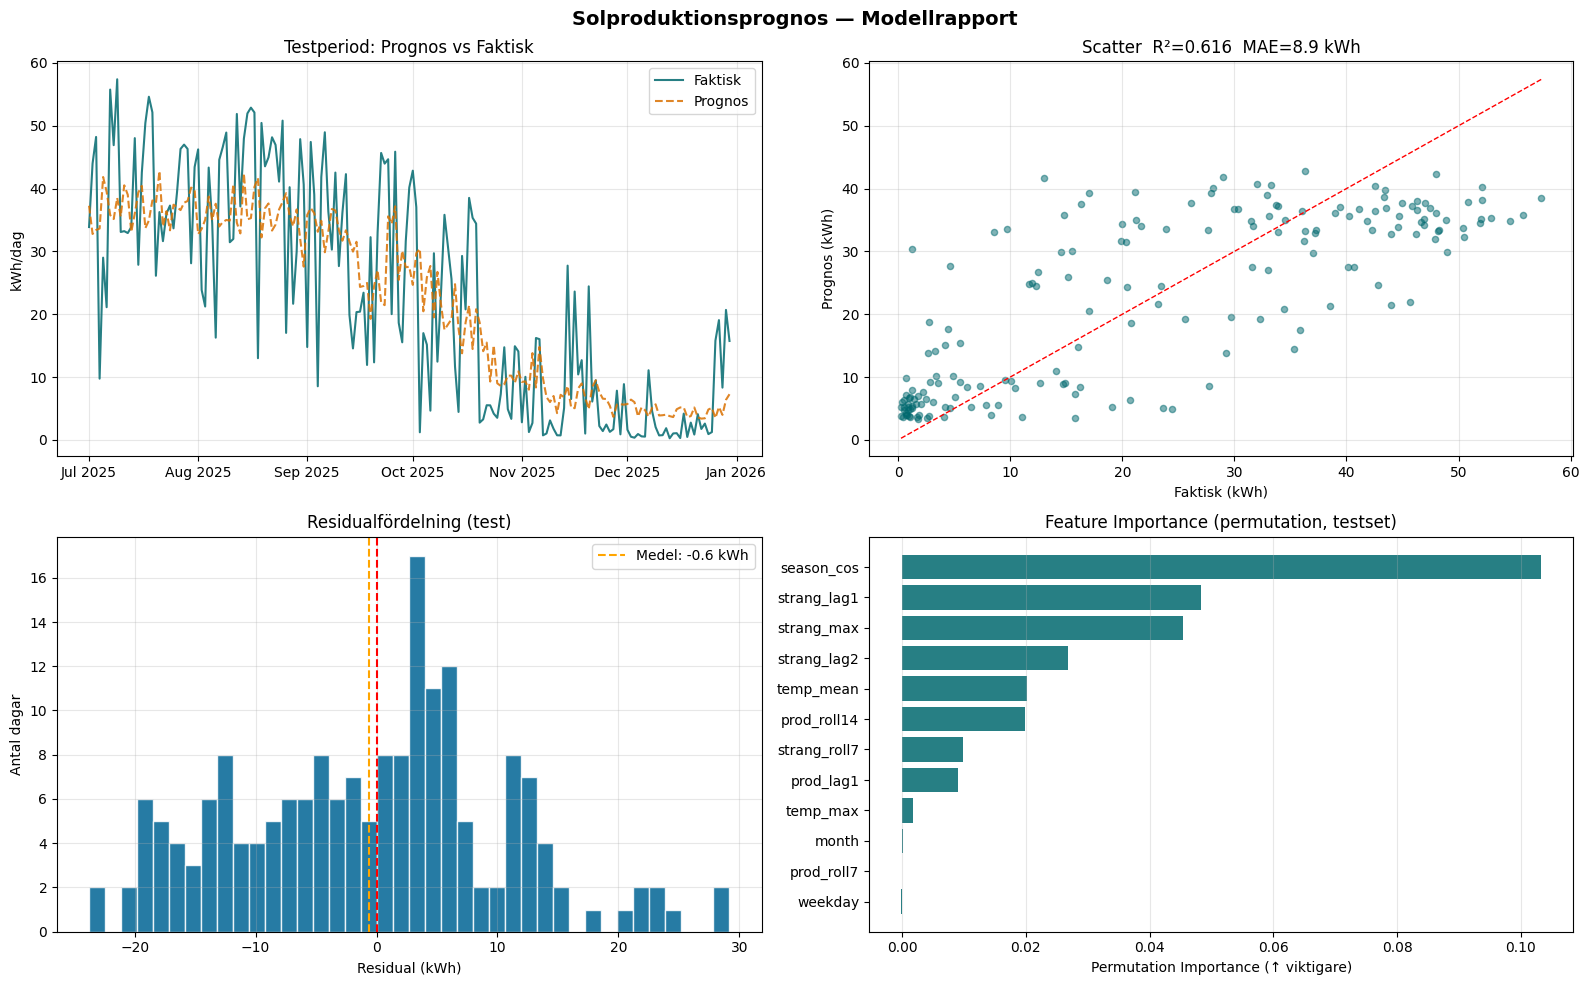

Rapport sparad: model_report.png


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Solproduktionsprognos — Modellrapport', fontsize=14, fontweight='bold')

# ── Panel 1: Prognos vs faktisk (testperiod) ──
ax = axes[0, 0]
ax.plot(daily.loc[mask_test].index, y_test.values,
        label='Faktisk', color='#01696f', linewidth=1.5, alpha=0.85)
ax.plot(daily.loc[mask_test].index, y_pred_test,
        label='Prognos', color='#da7101', linewidth=1.5, alpha=0.85, linestyle='--')
ax.set_title('Testperiod: Prognos vs Faktisk')
ax.set_ylabel('kWh/dag')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.legend()
ax.grid(alpha=0.3)

# ── Panel 2: Scatter prognos vs faktisk ──
ax = axes[0, 1]
ax.scatter(y_test, y_pred_test, alpha=0.5, color='#01696f', s=20)
lims = [min(y_test.min(), y_pred_test.min()), max(y_test.max(), y_pred_test.max())]
ax.plot(lims, lims, 'r--', linewidth=1)
ax.set_xlabel('Faktisk (kWh)'); ax.set_ylabel('Prognos (kWh)')
ax.set_title(f"Scatter  R²={res_test['r2']:.3f}  MAE={res_test['mae']:.1f} kWh")
ax.grid(alpha=0.3)

# ── Panel 3: Residualfördelning ──
ax = axes[1, 0]
residuals = y_pred_test - y_test.values
ax.hist(residuals, bins=40, color='#006494', edgecolor='white', alpha=0.85)
ax.axvline(0, color='red', linestyle='--')
ax.axvline(residuals.mean(), color='orange', linestyle='--',
           label=f'Medel: {residuals.mean():.1f} kWh')
ax.set_xlabel('Residual (kWh)'); ax.set_ylabel('Antal dagar')
ax.set_title('Residualfördelning (test)')
ax.legend(); ax.grid(alpha=0.3)

# ── Panel 4: Feature importance ──
ax = axes[1, 1]
imp_result = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42)
imp_df = pd.DataFrame({
    'feature': FEATURES,
    'importance': imp_result.importances_mean
}).sort_values('importance', ascending=True).tail(12)
bars = ax.barh(imp_df['feature'], imp_df['importance'], color='#01696f', alpha=0.85)
ax.set_xlabel('Permutation Importance (↑ viktigare)')
ax.set_title('Feature Importance (permutation, testset)')
ax.grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('model_report.png', dpi=150, bbox_inches='tight')
plt.show()
print("Rapport sparad: model_report.png")


## Sammanfattning av features för modellen

| Feature      | Vad den mäter                                                                                                                   |
| ------------ | ------------------------------------------------------------------------------------------------------------------------------- |
| season_cos   | Cosinustransformation av årets dag — berättar var i årscykeln vi är på ett cirkulärt korrekt sätt. Högst vikt av alla features. |
| season_sin   | Sinustransformation av samma sak — kompletterar season_cos för att fånga asymmetrin mellan vår och höst.                        |
| strang_lag1  | STRÅNG-strålningen igår i W/m² — proxy för om vädret var soligt senaste dygnet.                                                 |
| strang_lag2  | STRÅNG-strålningen i förrgår — fångar upp om ett väderläge håller i sig över flera dagar.                                       |
| strang_lag7  | Strålningen för exakt en vecka sedan — fångar veckosäsonsmönster och återkommande väderlägen.                                   |
| strang_max   | Högsta timvärdet för strålning under dagen — mäter om det någon gång under dagen var klart, även om medlet var lågt.            |
| strang_roll7 | Rullande 7-dagarmedel av strålning — jämnar ut brus och ger en stabil bild av det senaste väderläget.                           |
| temp_max     | Högsta temperaturen under dagen — korrelerat med soliga dagar eftersom kraftig sol värmer upp mer.                              |
| temp_mean    | Medeltemperaturen under dagen — komplement till temp_max, speglar även årstid och molnighet indirekt.                           |
| prod_lag1    | Faktisk solproduktion igår i kWh — direkt signal om hur panelerna presterade senast.                                            |
| prod_lag2    | Faktisk solproduktion i förrgår — fångar om ett bra eller dåligt väderläge håller i sig.                                        |
| prod_lag7    | Produktionen för exakt en vecka sedan — samma logik som strang_lag7 men baserat på faktiskt utfall.                             |
| prod_roll7   | Rullande 7-dagarmedel av produktion — stabiliserar mot kortsiktigt brus, liknar strang_roll7.                                   |
| prod_roll14  | Rullande 14-dagarmedel — längre horisont än roll7, fångar övergångar mellan säsonger bättre.                                    |
| month        | Kalendermånad (1–12) — delvis redundant med season_cos/sin men kan fånga månadsspecifika mönster.                               |
| weekday      | Veckodag (0–6) — solen bryr sig inte om veckodagen, därav nära noll i importance.                                               |
| is_weekend   | Helgflagga — liknande resonemang som weekday, minimal påverkan på solproduktion.                                                |

Några kommentarer:

1. I diagrammet Prognos vs Faktisk (övre vänster) ser vi hur prognosen inte är så dålig på att pricka trenden, men missar topparna och dalarna som är så viktiga för den här funktionen. Detta beror på att modellen saknar framåtblickande väderfeatures. Det är så det blir i en trädbaserad modell utan väderprognosinput. Detta får vi titta på i nästa steg.

2. Scatterdiagrammet har två tydliga mönster - på samma tema. Den underskattar höga värden och chansar aldrig på de riktigt soliga dagarna. 

3. Residualfördelningen (nedre vänster) visar att modellen är svagt pessimistisk och det får jag aceptera. Residualer upp mot +30 kWh är missade soliga sommardagar som modellen underskattar.

4. Listan på features som är viktiga för modellen visar föga överraskande att season_cos är viktigast medan veckodag är minst viktigt. 

Jag gjorde lite research och det visar sig att jag slarvat när jag hämtat NASA-data. Jag behöver komplettera med ALLSKY_KT (klarhetsindex).  låter delarna ovan stå kvar för att visa hur arbetsgången varit. 


In [58]:
# SMHI STRÅNG + läs NASA ALLSKY_KT från fil

# Hårdkodad period
date_from = datetime(2023, 7, 1, 0)
date_to   = datetime(2025, 12, 31, 23)

KT_CSV = r"Datainsamling/Del 3 - Data för projektet/nasa_allsky_kt.csv"

# ── Del A: STRÅNG ──────────────────────────────────────────────────────────

def fetch_strang_hourly(lat, lon, param, date_from, date_to):
    from_str = date_from.strftime('%Y%m%d%H')
    to_str   = date_to.strftime('%Y%m%d%H')
    url = (
        f"https://opendata-download-metanalys.smhi.se/api/category/strang1g"
        f"/version/1/geotype/point/lon/{lon}/lat/{lat}"
        f"/parameter/{param}/data.txt"
        f"?from={from_str}&to={to_str}&interval=hourly"
    )
    print("Hämtar STRÅNG...")
    r = requests.get(url, timeout=60)
    r.raise_for_status()
    rows = []
    for line in r.text.strip().splitlines():
        parts = line.split()
        if len(parts) == 5:
            try:
                ts = pd.Timestamp(
                    year=int(parts[0]), month=int(parts[1]),
                    day=int(parts[2]),  hour=int(parts[3]),
                    tz='UTC'
                ).tz_convert('Europe/Stockholm').tz_localize(None)
                rows.append((ts, float(parts[4])))
            except ValueError:
                continue
    s = pd.Series({ts: v for ts, v in rows}, name='strang_ghi_wm2')
    s = s.replace(-999, np.nan)
    print(f"STRÅNG: {len(s):,} timmar | Saknade: {s.isna().sum()} | Max: {s.max():.0f} W/m²")
    return s

strang_series = fetch_strang_hourly(LAT, LON, STRANG_PARAM, date_from, date_to)

# ── Del B: NASA ALLSKY_KT från fil ────────────────────────────────────────

kt_series = pd.read_csv(
    KT_CSV,
    index_col='timestamp',
    parse_dates=['timestamp']
)['allsky_kt']

kt_series = kt_series.groupby(kt_series.index).mean()

df_master['allsky_kt'] = df_master.index.astype('datetime64[ns]').map(kt_series)

print(f"ALLSKY_KT: {len(kt_series):,} timmar | Period: {kt_series.index.min().date()} → {kt_series.index.max().date()}")
print(f"Matchade rader:  {df_master['allsky_kt'].notna().sum():,} av {len(df_master):,}")
print(f"Saknade:         {df_master['allsky_kt'].isna().sum()}")

Hämtar STRÅNG...
STRÅNG: 21,957 timmar | Saknade: 192 | Max: 871 W/m²
ALLSKY_KT: 21,960 timmar | Period: 2023-07-01 → 2025-12-31
Matchade rader:  11,115 av 21,961
Saknade:         10846


In [ ]:
# SMHI metobs: timvis lufttemperatur för flygplatsen som bara är några km bort

METOBS_CSV = r"Datainsamling/Del 3 - Data för projektet/smhi_metobs.csv"

def fetch_metobs_temperature(station_id):
    base   = "https://opendata-download-metobs.smhi.se/api/version/1.0"
    frames = []

    for period in ['corrected-archive', 'latest-months']:
        url = f"{base}/parameter/1/station/{station_id}/period/{period}/data.csv"
        try:
            r = requests.get(url, timeout=30)
            r.raise_for_status()
            lines      = r.content.decode('utf-8-sig').splitlines()
            data_start = next(
                i for i, l in enumerate(lines)
                if l.startswith('Datum') or l.startswith('datum')
            )
            csv_text = '\n'.join(lines[data_start:])
            tmp = pd.read_csv(
                StringIO(csv_text),
                sep=';',
                usecols=[0, 1, 2],
                names=['datum', 'tid_utc', 'temp_obs'],
                skiprows=1,
                dtype={'temp_obs': str}
            )
            tmp['timestamp'] = pd.to_datetime(
                tmp['datum'] + ' ' + tmp['tid_utc'],
                utc=True,
                errors='coerce'
            ).dt.tz_convert('Europe/Stockholm').dt.tz_localize(None)
            tmp['temp_obs'] = pd.to_numeric(tmp['temp_obs'], errors='coerce')
            frames.append(tmp[['timestamp', 'temp_obs']].dropna())
            print(f"  Period '{period}': {len(tmp)} rader")
        except Exception as e:
            print(f"  Period '{period}': hoppades över ({e})")

    df_obs = pd.concat(frames).drop_duplicates('timestamp')
    df_obs = df_obs.set_index('timestamp').sort_index()['temp_obs']
    df_obs.name = 'temp_obs_c'

    # Spara som CSV
    df_obs.to_csv(METOBS_CSV, index=True, index_label='timestamp')

    print(f"\nMetobs temp: {len(df_obs):,} timmar | "
          f"Period: {df_obs.index.min().date()} → {df_obs.index.max().date()} | "
          f"Sparad: {METOBS_CSV}")
    return df_obs


temp_obs = fetch_metobs_temperature(STATION_ID)
temp_obs.head()

  Period 'corrected-archive': 255944 rader
  Period 'latest-months': 3133 rader

Metobs temp: 258,419 timmar | Period: 1945-02-06 → 2026-04-14 | Sparad: Datainsamling/Del 3 - Data för projektet/smhi_metobs.csv


timestamp
1945-02-06 08:00:00   0.400
1945-02-06 14:00:00   1.000
1945-02-07 08:00:00   1.200
1945-02-07 14:00:00   1.800
1945-02-08 08:00:00   1.800
Name: temp_obs_c, dtype: float64

In [59]:
# Slå ihop datakällor och bygg dagliga features

df = df_master.copy()
df['strang_ghi_wm2'] = strang_series
df['temp_obs']       = temp_obs

# Interpolera korta luckor i STRÅNG (max 2h)
df['strang_ghi_wm2'] = df['strang_ghi_wm2'].interpolate(method='time', limit=2)

# ── Kalenderfeatures ──
df['hour']        = df.index.hour
df['month']       = df.index.month
df['weekday']     = df.index.dayofweek
df['day_of_year'] = df.index.dayofyear

# ── Solhöjdsapproximation ──
df['solar_angle'] = np.sin(
    np.pi * (df['hour'] - 6) / 14
).clip(lower=0)

# ── Daglig aggregering ──
daily = df.resample('D').agg(
    production     = ('total_production_kwh', 'sum'),
    strang_mean    = ('strang_ghi_wm2', 'mean'),
    strang_max     = ('strang_ghi_wm2', 'max'),
    kt_mean        = ('allsky_kt', 'mean'),   
    kt_max         = ('allsky_kt', 'max'),    
    temp_max       = ('temp_obs', 'max'),
    temp_mean      = ('temp_obs', 'mean'),
    house_load_sum = ('total_house_load_kwh', 'sum'),
    month          = ('month', 'first'),
    weekday        = ('weekday', 'first'),
    day_of_year    = ('day_of_year', 'first'),
).dropna(subset=['production', 'strang_mean'])

# ── Laggade features ──
for lag in [1, 2, 7]:
    daily[f'prod_lag{lag}']   = daily['production'].shift(lag)
    daily[f'strang_lag{lag}'] = daily['strang_mean'].shift(lag)
    daily[f'kt_lag{lag}']     = daily['kt_mean'].shift(lag)   # NY

daily['prod_roll7']   = daily['production'].shift(1).rolling(7).mean()
daily['prod_roll14']  = daily['production'].shift(1).rolling(14).mean()
daily['strang_roll7'] = daily['strang_mean'].shift(1).rolling(7).mean()

# ── Årstidscykel ──
daily['season_sin'] = np.sin(2 * np.pi * daily['day_of_year'] / 365.25)
daily['season_cos'] = np.cos(2 * np.pi * daily['day_of_year'] / 365.25)

# Target = nästa dags produktion
daily['target'] = daily['production'].shift(-1)
daily = daily.dropna()

print(f"Datamängd redo: {len(daily)} dagar")
print(f"Träning (< {TRAIN_CUTOFF}): {(daily.index < TRAIN_CUTOFF).sum()} dagar")
print(f"Test   (≥ {TRAIN_CUTOFF}): {(daily.index >= TRAIN_CUTOFF).sum()} dagar")
daily.head(3)

Datamängd redo: 892 dagar
Träning (< 2025-07-01): 710 dagar
Test   (≥ 2025-07-01): 182 dagar


,production,strang_mean,strang_max,kt_mean,kt_max,temp_max,temp_mean,house_load_sum,month,weekday,...,kt_lag2,prod_lag7,strang_lag7,kt_lag7,prod_roll7,prod_roll14,strang_roll7,season_sin,season_cos,target
timestamp,,,,,,,,,,,,,,,,,,,,,
2023-07-15,24.525,205.487,674.700,0.366,0.540,26.100,19.754,47.425,7,5,...,0.464,56.102,331.250,0.631,40.874,36.632,260.129,-0.228,-0.974,40.077
2023-07-16,40.077,250.362,791.600,0.406,0.620,21.800,18.954,51.577,7,6,...,0.528,55.834,326.050,0.592,36.363,37.906,242.163,-0.245,-0.970,45.520
2023-07-17,45.520,245.112,767.800,0.399,0.590,19.400,17.062,39.520,7,0,...,0.366,13.103,150.908,0.208,34.112,37.389,231.351,-0.261,-0.965,37.902


In [66]:
# Träna modellen

FEATURES = [
    'strang_lag1', 'strang_lag2', 'strang_lag7', 'strang_roll7',
    'strang_max',
    'kt_lag1', 'kt_lag2', 'kt_lag7',   
    'kt_mean', 'kt_max',               
    'temp_max', 'temp_mean',
    'prod_lag1', 'prod_lag2', 'prod_lag7',
    'prod_roll7', 'prod_roll14',
    'month', 'weekday', 'season_sin', 'season_cos',
]

mask_train = daily.index < TRAIN_CUTOFF
mask_test  = daily.index >= TRAIN_CUTOFF

X_train = daily.loc[mask_train, FEATURES]
y_train = daily.loc[mask_train, 'target']
X_test  = daily.loc[mask_test,  FEATURES]
y_test  = daily.loc[mask_test,  'target']

model = HistGradientBoostingRegressor(
    max_iter            = 1000,
    learning_rate       = 0.02,
    max_depth           = 4,
    min_samples_leaf    = 2,
    l2_regularization   = 0.1,
    random_state        = 42,
    early_stopping      = True,
    validation_fraction = 0.15,
    n_iter_no_change    = 50,
    loss                = 'quantile',
    quantile            = 0.6
)
model.fit(X_train, y_train)

y_pred_train = model.predict(X_train)
y_pred_test  = model.predict(X_test)

def metrics(y_true, y_pred, label):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f"{label:10}  MAE={mae:.2f} kWh  RMSE={rmse:.2f} kWh  R²={r2:.4f}")
    return {'mae': mae, 'rmse': rmse, 'r2': r2}

print(f"Antal träningsdagar: {len(X_train)}")
print(f"Tidiga stopp vid iteration: {model.n_iter_}")
print()
res_train = metrics(y_train, y_pred_train, "TRÄNING")
res_test  = metrics(y_test,  y_pred_test,  "TEST")

Antal träningsdagar: 710
Tidiga stopp vid iteration: 319

TRÄNING     MAE=7.35 kWh  RMSE=10.53 kWh  R²=0.6814
TEST        MAE=8.81 kWh  RMSE=11.63 kWh  R²=0.5719


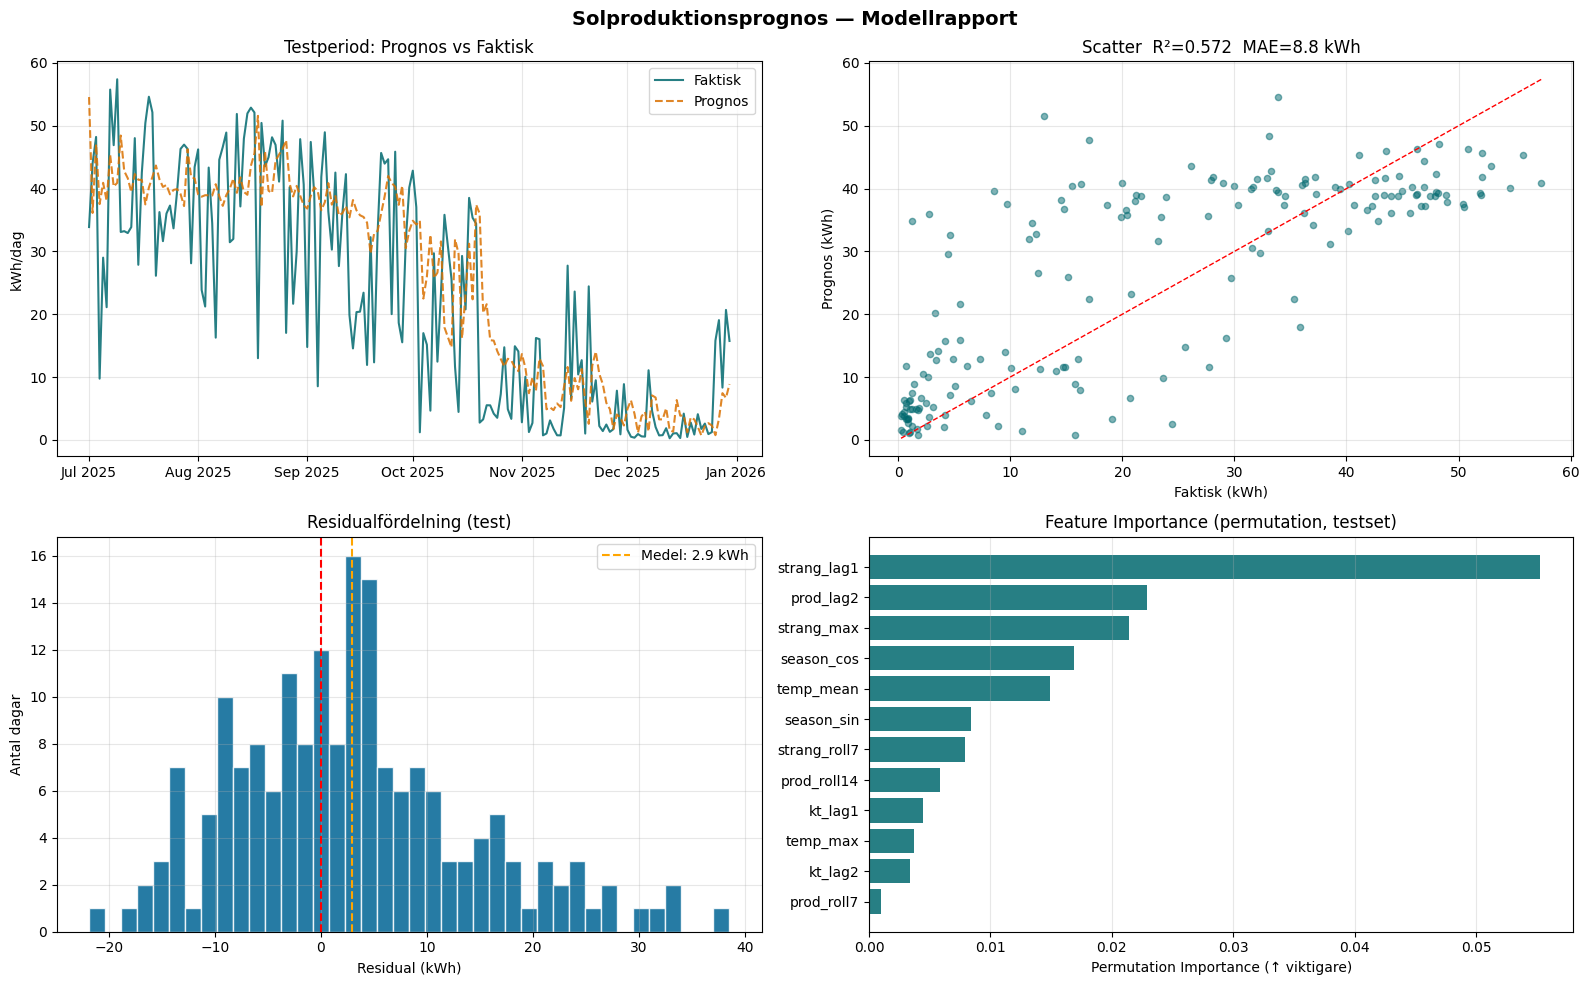

Rapport sparad: model_report.png


In [67]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Solproduktionsprognos — Modellrapport', fontsize=14, fontweight='bold')

# ── Panel 1: Prognos vs faktisk (testperiod) ──
ax = axes[0, 0]
ax.plot(daily.loc[mask_test].index, y_test.values,
        label='Faktisk', color='#01696f', linewidth=1.5, alpha=0.85)
ax.plot(daily.loc[mask_test].index, y_pred_test,
        label='Prognos', color='#da7101', linewidth=1.5, alpha=0.85, linestyle='--')
ax.set_title('Testperiod: Prognos vs Faktisk')
ax.set_ylabel('kWh/dag')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.legend()
ax.grid(alpha=0.3)

# ── Panel 2: Scatter prognos vs faktisk ──
ax = axes[0, 1]
ax.scatter(y_test, y_pred_test, alpha=0.5, color='#01696f', s=20)
lims = [min(y_test.min(), y_pred_test.min()), max(y_test.max(), y_pred_test.max())]
ax.plot(lims, lims, 'r--', linewidth=1)
ax.set_xlabel('Faktisk (kWh)'); ax.set_ylabel('Prognos (kWh)')
ax.set_title(f"Scatter  R²={res_test['r2']:.3f}  MAE={res_test['mae']:.1f} kWh")
ax.grid(alpha=0.3)

# ── Panel 3: Residualfördelning ──
ax = axes[1, 0]
residuals = y_pred_test - y_test.values
ax.hist(residuals, bins=40, color='#006494', edgecolor='white', alpha=0.85)
ax.axvline(0, color='red', linestyle='--')
ax.axvline(residuals.mean(), color='orange', linestyle='--',
           label=f'Medel: {residuals.mean():.1f} kWh')
ax.set_xlabel('Residual (kWh)'); ax.set_ylabel('Antal dagar')
ax.set_title('Residualfördelning (test)')
ax.legend(); ax.grid(alpha=0.3)

# ── Panel 4: Feature importance ──
ax = axes[1, 1]
imp_result = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42)
imp_df = pd.DataFrame({
    'feature': FEATURES,
    'importance': imp_result.importances_mean
}).sort_values('importance', ascending=True).tail(12)
bars = ax.barh(imp_df['feature'], imp_df['importance'], color='#01696f', alpha=0.85)
ax.set_xlabel('Permutation Importance (↑ viktigare)')
ax.set_title('Feature Importance (permutation, testset)')
ax.grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('model_report.png', dpi=150, bbox_inches='tight')
plt.show()
print("Rapport sparad: model_report.png")


Nej, det är - som väntat egentligen - inte så lätt att "spå väder" med en modell som arbetar med historiska data. 

I diagrammet Prognos vs Faktisk ser vi dock att prognosen nu vågar ta ut svängarna lite mer och inte längre följer trenden lika passivt.

Som vi ser i scatterdiagrammet betyder den här "våghalsigheten" dock att den totala träffsäkerheten faktiskt sjönk lite, men det är så det blir när modellen vågar ta större risker.

Feature importance visar dock att strang_lag1 klättrat upp i topp, vilket visar att ALLSKY_KT-tillägget  förskjutit modellens fokus mot mer kortsiktiga väderfeatures. Alltid något.

Slutsatsen är att ALLSKY_KT inte räcker för att lyfta modellens prediktionsförmåga i någon större utsträckning. Historiska data är fortfarande historiska och lösningen blir en framåtblickande molntäckningsprognos från SMHI. Här lade jag en del tid på att försöka få tillgång till pmp3g med benäget bistånd av AI. Varken min AI eller jag hade koll på att SMHI stängde den funktionen för ett par veckor sedan och ersatte med en annan. snow1g.

In [ ]:
# ── Hämta snow1g-prognos ─────────────────────────────────────────────────────

def fetch_snow1g_forecast(lat, lon):
    url = (
        f"https://opendata-download-metfcst.smhi.se/api/category/snow1g"
        f"/version/1/geotype/point/lon/{lon}/lat/{lat}/data.json"
    )
    r = requests.get(url, timeout=15)
    r.raise_for_status()
    data = r.json()

    rows = []
    for step in data['timeSeries']:
        ts  = pd.Timestamp(step['time']).tz_convert('Europe/Stockholm').tz_localize(None)
        d   = step['data']
        rows.append({
            'timestamp':         ts,
            'temp_c':            d.get('air_temperature'),
            'humidity_pct':      d.get('relative_humidity'),
            'cloud_total_octas': d.get('cloud_area_fraction'),
            'cloud_low_octas':   d.get('low_type_cloud_area_fraction'),
            'weather_symbol':    d.get('symbol_code'),
        })

    df_fcst = pd.DataFrame(rows).set_index('timestamp')
    # Molntäckning oktanter → procent
    for col in ['cloud_total_octas', 'cloud_low_octas']:
        df_fcst[col.replace('octas', 'pct')] = df_fcst[col] * (100 / 8)
    return df_fcst


# ── Bygg feature-vektor ───────────────────────────────────────────────────────

def build_tomorrow_features(daily_df, snow1g_df):
    tomorrow  = (pd.Timestamp.now() + pd.Timedelta(days=1)).date()
    tmrw_fcst = snow1g_df[snow1g_df.index.date == tomorrow]
    solar     = tmrw_fcst.between_time('06:00', '20:00')

    # Molntäckning 
    cloud_mean   = solar['cloud_total_pct'].mean() / 100
    cloud_min    = solar['cloud_total_pct'].min()  / 100
    cloud_heavy  = (solar['cloud_total_pct'] > 75).mean()
    cloud_factor = 1 - cloud_mean
    bad_wx_frac  = (solar['weather_symbol'] >= 7).mean() if 'weather_symbol' in solar.columns else 0.0

    # Approximera STRÅNG för imorgon baserat på årstid + molntäckning
    month         = tomorrow.month
    clear_sky_max = 200 + 600 * np.sin(np.pi * (month - 1) / 11)
    strang_est    = clear_sky_max * cloud_factor

    features = {
        # STRÅNG-features från historik (finns i daily)
        'strang_lag1':   daily_df['strang_mean'].iloc[-1],
        'strang_lag2':   daily_df['strang_mean'].iloc[-2] if len(daily_df) > 1 else daily_df['strang_mean'].iloc[-1],
        'strang_lag7':   daily_df['strang_mean'].iloc[-7] if len(daily_df) > 6 else daily_df['strang_mean'].iloc[-1],
        'strang_roll7':  daily_df['strang_mean'].iloc[-7:].mean(),
        'strang_max':    strang_est * 1.3,

        # KT-features — historik + prognos-proxy
        'kt_lag1':       daily_df['kt_mean'].iloc[-1],
        'kt_lag2':       daily_df['kt_mean'].iloc[-2] if len(daily_df) > 1 else daily_df['kt_mean'].iloc[-1],
        'kt_lag7':       daily_df['kt_mean'].iloc[-7] if len(daily_df) > 6 else daily_df['kt_mean'].iloc[-1],
        'kt_mean':       cloud_factor,
        'kt_max':        min(cloud_factor * 1.2, 1.0),

        # Temperatur från snow1g
        'temp_max':      tmrw_fcst['temp_c'].max(),
        'temp_mean':     tmrw_fcst['temp_c'].mean(),

        # Produktions-features från historik
        'prod_lag1':     daily_df['production'].iloc[-1],
        'prod_lag2':     daily_df['production'].iloc[-2] if len(daily_df) > 1 else daily_df['production'].iloc[-1],
        'prod_lag7':     daily_df['production'].iloc[-7] if len(daily_df) > 6 else daily_df['production'].iloc[-1],
        'prod_roll7':    daily_df['production'].iloc[-7:].mean(),
        'prod_roll14':   daily_df['production'].iloc[-14:].mean(),

        # Kalenderfeatures
        'month':         tomorrow.month,
        'weekday':       tomorrow.weekday(),
        'season_sin':    np.sin(2 * np.pi * tomorrow.timetuple().tm_yday / 365.25),
        'season_cos':    np.cos(2 * np.pi * tomorrow.timetuple().tm_yday / 365.25),
    }
    return features, tomorrow


# Kör

snow1g_df = fetch_snow1g_forecast(LAT, LON)
print(f"snow1g: {len(snow1g_df)} timmar | {snow1g_df.index.min().date()} → {snow1g_df.index.max().date()}")

features_tomorrow, tomorrow_date = build_tomorrow_features(daily, snow1g_df)
X_pred = pd.DataFrame([features_tomorrow])[FEATURES]

predicted_kwh = max(0, model.predict(X_pred)[0])

print(f"\nPrognos för: {tomorrow_date}")
print(f"🌤 Molntäckning (snitt soltimmar): {snow1g_df[snow1g_df.index.date == tomorrow_date]['cloud_total_pct'].mean():.0f}%")
print(f"🌡 Temperatur max: {snow1g_df[snow1g_df.index.date == tomorrow_date]['temp_c'].max():.1f}°C")
print(f"⚡ Prognos produktion: {predicted_kwh:.1f} kWh")

snow1g: 82 timmar | 2026-04-14 → 2026-04-25

Prognos för: 2026-04-15
🌤 Molntäckning (snitt soltimmar): 83%
🌡 Temperatur max: 8.3°C
⚡ Prognos produktion: 22.9 kWh


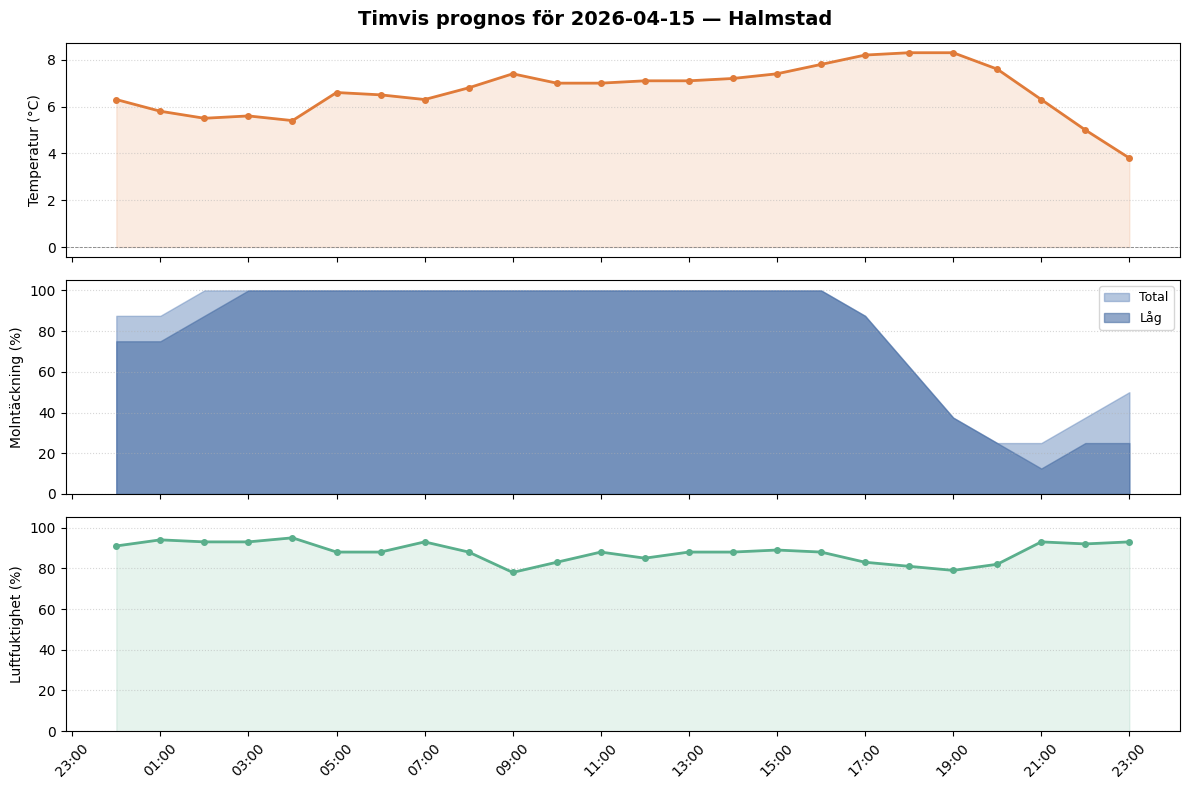

Sparad: prognos_imorgon_timvis.png


In [79]:
# Timvis data för imorgon
tmrw_hourly = snow1g_df[snow1g_df.index.date == tomorrow_date].copy()

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
fig.suptitle(f"Timvis prognos för {tomorrow_date} — Halmstad", fontsize=14, fontweight='bold')

# Temperatur
axes[0].plot(tmrw_hourly.index, tmrw_hourly['temp_c'], color='#e07b39', linewidth=2, marker='o', markersize=4)
axes[0].axhline(0, color='gray', linewidth=0.6, linestyle='--')
axes[0].set_ylabel('Temperatur (°C)')
axes[0].fill_between(tmrw_hourly.index, tmrw_hourly['temp_c'], alpha=0.15, color='#e07b39')
axes[0].grid(axis='y', linestyle=':', alpha=0.5)

# Molntäckning
axes[1].fill_between(tmrw_hourly.index, tmrw_hourly['cloud_total_pct'],
                     label='Total', alpha=0.5, color='#6c8ebf')
axes[1].fill_between(tmrw_hourly.index, tmrw_hourly['cloud_low_pct'],
                     label='Låg', alpha=0.6, color='#4a6fa5')
axes[1].set_ylabel('Molntäckning (%)')
axes[1].set_ylim(0, 105)
axes[1].legend(loc='upper right', fontsize=9)
axes[1].grid(axis='y', linestyle=':', alpha=0.5)

# Luftfuktighet
axes[2].plot(tmrw_hourly.index, tmrw_hourly['humidity_pct'], color='#5aaf8c', linewidth=2, marker='o', markersize=4)
axes[2].set_ylabel('Luftfuktighet (%)')
axes[2].set_ylim(0, 105)
axes[2].fill_between(tmrw_hourly.index, tmrw_hourly['humidity_pct'], alpha=0.15, color='#5aaf8c')
axes[2].grid(axis='y', linestyle=':', alpha=0.5)

axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
axes[2].xaxis.set_major_locator(mdates.HourLocator(interval=2))
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('prognos_imorgon_timvis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Sparad: prognos_imorgon_timvis.png")

Testperiod:  2025-07-04 → 2025-12-30  (179 dagar)
MAE:  7.90 kWh
RMSE: 10.29 kWh
R²:   0.667


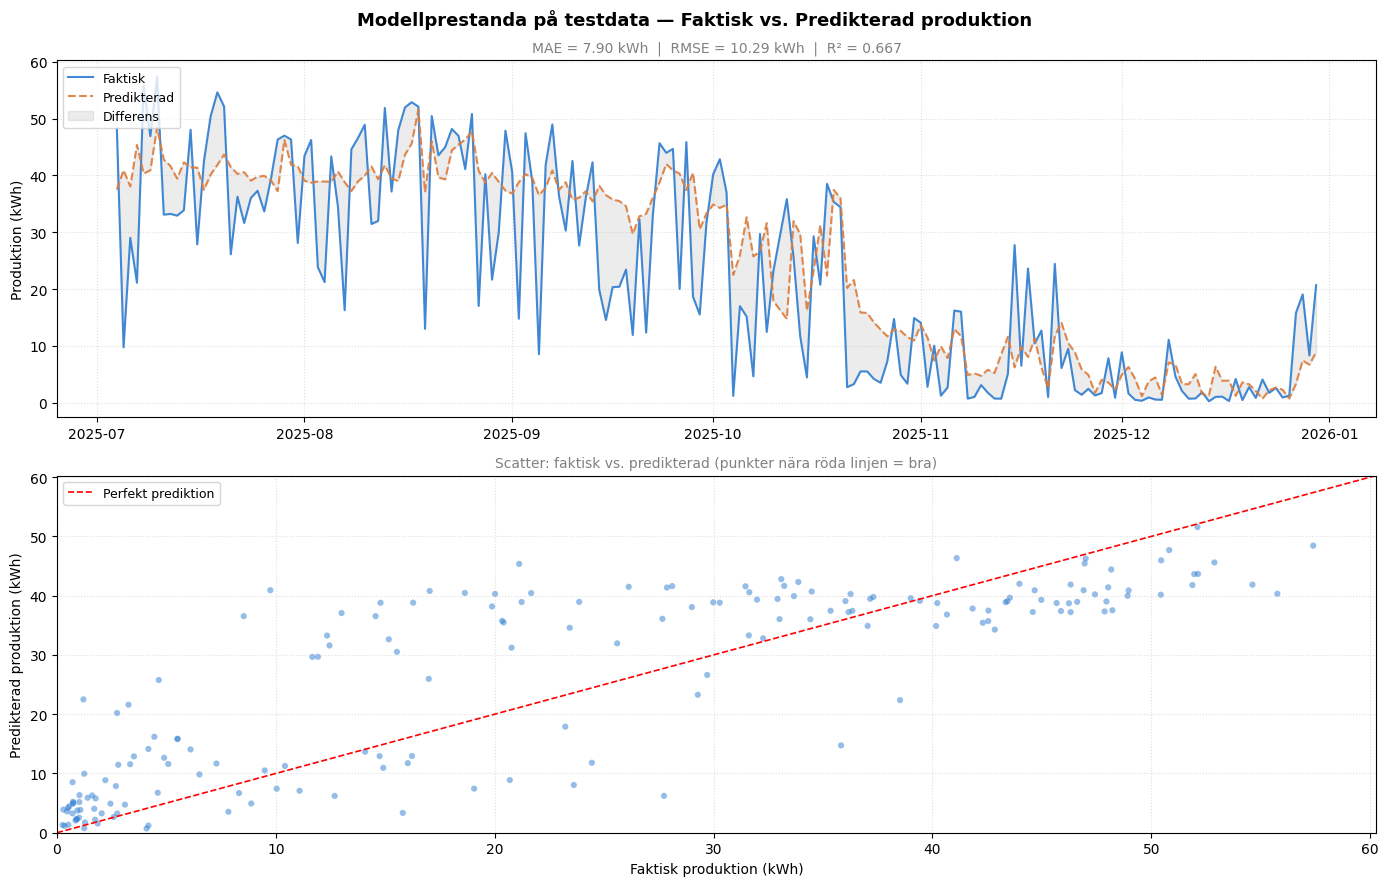

Sparad: backtest_modell.png


In [81]:
# Ta fram ett nytt testset (lite fusk)
TEST_RATIO = 0.2   

split_idx    = int(len(daily) * (1 - TEST_RATIO))
test_df      = daily.iloc[split_idx:].copy()
X_test_bt    = test_df[FEATURES]
y_test_bt    = test_df['production']
test_dates   = test_df.index

y_pred_bt    = model.predict(X_test_bt)

mae  = mean_absolute_error(y_test_bt, y_pred_bt)
rmse = mean_squared_error(y_test_bt, y_pred_bt) ** 0.5
r2   = r2_score(y_test_bt, y_pred_bt)

print(f"Testperiod:  {test_dates.min().date()} → {test_dates.max().date()}  ({len(test_df)} dagar)")
print(f"MAE:  {mae:.2f} kWh")
print(f"RMSE: {rmse:.2f} kWh")
print(f"R²:   {r2:.3f}")

# Visualisering 
fig, axes = plt.subplots(2, 1, figsize=(14, 9))
fig.suptitle("Modellprestanda på testdata — Faktisk vs. Predikterad produktion",
             fontsize=13, fontweight='bold')

# Panel 1: tidsserie
axes[0].plot(test_dates, y_test_bt,  label='Faktisk',     color='#2d7dd2', linewidth=1.5, alpha=0.9)
axes[0].plot(test_dates, y_pred_bt,  label='Predikterad', color='#e07b39', linewidth=1.5,
             linestyle='--', alpha=0.9)
axes[0].fill_between(test_dates, y_test_bt, y_pred_bt,
                     alpha=0.15, color='gray', label='Differens')
axes[0].set_ylabel('Produktion (kWh)')
axes[0].legend(loc='upper left', fontsize=9)
axes[0].grid(linestyle=':', alpha=0.4)
axes[0].set_title(f'MAE = {mae:.2f} kWh  |  RMSE = {rmse:.2f} kWh  |  R² = {r2:.3f}',
                  fontsize=10, color='gray')

# Panel 2: scatter faktisk vs predikterad
max_val = max(y_test_bt.max(), y_pred_bt.max()) * 1.05
axes[1].scatter(y_test_bt, y_pred_bt, alpha=0.5, s=20, color='#2d7dd2', edgecolors='none')
axes[1].plot([0, max_val], [0, max_val], 'r--', linewidth=1.2, label='Perfekt prediktion')
axes[1].set_xlabel('Faktisk produktion (kWh)')
axes[1].set_ylabel('Predikterad produktion (kWh)')
axes[1].set_xlim(0, max_val)
axes[1].set_ylim(0, max_val)
axes[1].legend(fontsize=9)
axes[1].grid(linestyle=':', alpha=0.4)
axes[1].set_title('Scatter: faktisk vs. predikterad (punkter nära röda linjen = bra)',
                  fontsize=10, color='gray')

plt.tight_layout()
plt.savefig('backtest_modell.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Sparad: backtest_modell.png")